Tickers loaded: ['AGL.JO', 'EEM', 'FSR.JO', 'GLD', 'NPN.JO', 'QQQ', 'SHP.JO', 'SOL.JO', 'SPY', 'TLT']
Delta: 3.0829
Risk-free rate: 3.50%

Implied returns loaded:
AGL.JO    0.097100
EEM       0.089000
FSR.JO    0.115200
GLD       0.168600
NPN.JO    0.090200
QQQ       0.060400
SHP.JO    0.065600
SOL.JO    0.073200
SPY       0.022000
TLT      -0.003000
Name: Implied Return, dtype: float64

All inputs ready ✓
Asset index map:
  Column 0: AGL.JO
  Column 1: EEM
  Column 2: FSR.JO
  Column 3: GLD
  Column 4: NPN.JO
  Column 5: QQQ
  Column 6: SHP.JO
  Column 7: SOL.JO
  Column 8: SPY
  Column 9: TLT

P Matrix (Picks Matrix):
                       AGL.JO      EEM   FSR.JO      GLD    NPN.JO      QQQ   SHP.JO   SOL.JO      SPY       TLT
View 1: FSR vs NPN   0.000000 0.000000 1.000000 0.000000 -1.000000 0.000000 0.000000 0.000000 0.000000  0.000000
View 2: GLD vs TLT   0.000000 0.000000 0.000000 1.000000  0.000000 0.000000 0.000000 0.000000 0.000000 -1.000000
View 3: EEM Absolute 0.000000 1.0

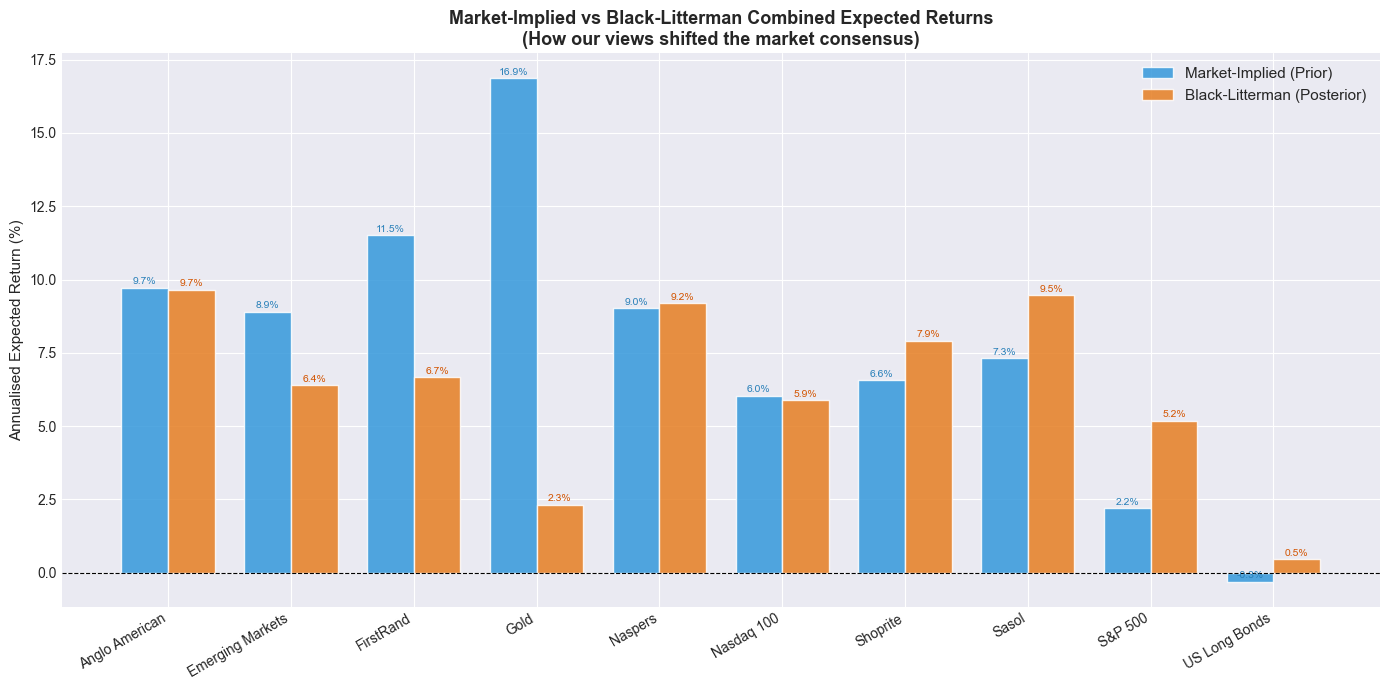

Chart saved ✓
BL Posterior Covariance Matrix shape: (10, 10)

Diagonal (annualised variances per asset):
  AGL.JO      Variance: 0.173251   Volatility: 41.62%
  EEM         Variance: 0.105597   Volatility: 32.50%
  FSR.JO      Variance: 0.155101   Volatility: 39.38%
  GLD         Variance: 0.439602   Volatility: 66.30%
  NPN.JO      Variance: 0.097905   Volatility: 31.29%
  QQQ         Variance: 0.042933   Volatility: 20.72%
  SHP.JO      Variance: 0.062567   Volatility: 25.01%
  SOL.JO      Variance: 0.049116   Volatility: 22.16%
  SPY         Variance: 0.026291   Volatility: 16.21%
  TLT         Variance: 0.033040   Volatility: 18.18%
Optimised Portfolio Weights (Max Sharpe):
  NPN.JO      20.00%  ████████████
  FSR.JO       9.42%  █████
  AGL.JO      20.00%  ████████████
  SOL.JO       6.86%  ████
  SHP.JO      20.00%  ████████████
  SPY          2.88%  █
  QQQ          9.82%  █████
  EEM         11.02%  ██████

  TOTAL       100.00%

  Constraint check — max weight ≤ 20%: ✓ PASS
╔═

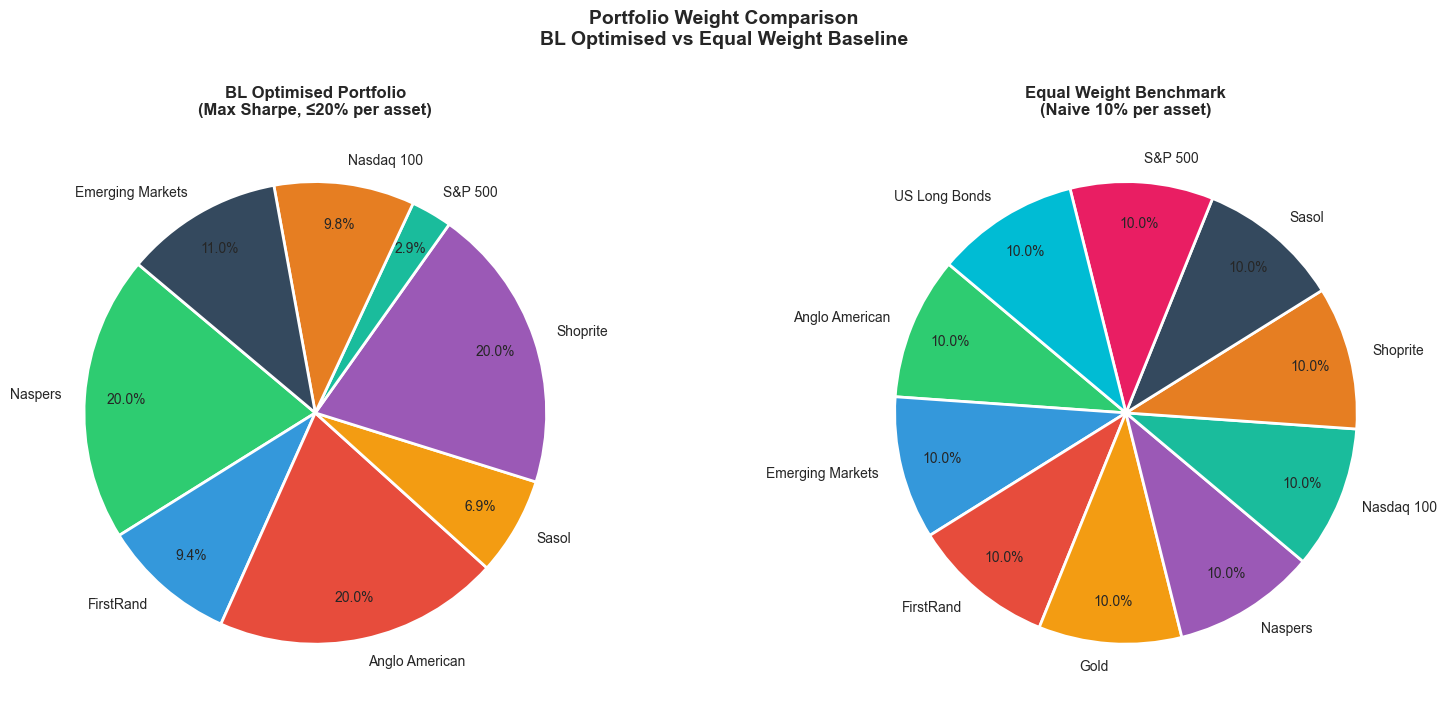

Chart saved ✓
Files saved:
  → data/optimised_weights.csv
  → data/benchmark_weights.csv
  → data/performance_comparison.csv

Step 3 Complete ✓


In [14]:
# ── Standard tools ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── PyPortfolioOpt — the workhorse of this step ───────────────────────
from pypfopt import BlackLittermanModel      # The BL formula
from pypfopt import EfficientFrontier        # The quadratic optimiser
from pypfopt import risk_models              # Covariance tools
from pypfopt import plotting                 # Built-in portfolio charts
from pypfopt.objective_functions import L2_reg  # Regularisation (explained later)

# ── Display settings ──────────────────────────────────────────────────
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Load everything saved from Steps 1 and 2 ─────────────────────────
prices         = pd.read_csv("../data/clean_prices.csv",      index_col=0, parse_dates=True)
cov_matrix_lw  = pd.read_csv("../data/cov_matrix_lw.csv",    index_col=0)
implied_returns= pd.read_csv("../data/implied_returns.csv",   index_col=0).squeeze("columns")
model_params   = pd.read_csv("../data/model_parameters.csv",  index_col=0).squeeze("columns")

# ── Reconstruct key variables ─────────────────────────────────────────
tickers        = list(prices.columns)
delta          = float(model_params.loc["delta"])
risk_free_rate = float(model_params.loc["risk_free_rate"])
S              = cov_matrix_lw.values    # Sigma — the covariance matrix

# Fix index name if needed
implied_returns.index = tickers

asset_names = {
    "NPN.JO": "Naspers",       "FSR.JO": "FirstRand",
    "AGL.JO": "Anglo American","SOL.JO": "Sasol",
    "SHP.JO": "Shoprite",      "SPY":    "S&P 500",
    "QQQ":    "Nasdaq 100",    "EEM":    "Emerging Markets",
    "GLD":    "Gold",          "TLT":    "US Long Bonds",
}

print(f"Tickers loaded: {tickers}")
print(f"Delta: {delta:.4f}")
print(f"Risk-free rate: {risk_free_rate:.2%}")
print("\nImplied returns loaded:")
print(implied_returns.round(4))

print("\nAll inputs ready ✓")

# ══════════════════════════════════════════════════════════════════════
# VIEW FORMULATION — Read every comment carefully
# ══════════════════════════════════════════════════════════════════════
#
# Context for our views (pretend today is early 2024):
#
# View 1 — RELATIVE
#   SA Financials (FirstRand) will OUTPERFORM SA Tech/Consumer (Naspers)
#   by 2% per annum.
#   Reasoning: SA interest rates peaked, benefiting banks. Naspers
#   faces pressure from Chinese tech regulation (it owns ~26% of Tencent).
#
# View 2 — RELATIVE
#   Gold (GLD) will OUTPERFORM US Long Bonds (TLT) by 1.5% per annum.
#   Reasoning: Geopolitical uncertainty and sticky inflation favour
#   gold as a store of value over bonds, which suffer from rate risk.
#
# View 3 — ABSOLUTE
#   Emerging Markets (EEM) will deliver a positive absolute return
#   of 5% per annum.
#   Reasoning: EM valuations are attractive relative to US equities,
#   and a weaker USD environment benefits EM assets.
#
# ══════════════════════════════════════════════════════════════════════

# ── P Matrix: the "picks" matrix ──────────────────────────────────────
# Shape: (number_of_views × number_of_assets)
# Each ROW is one view.
# Each COLUMN corresponds to one asset (in ticker order).
#
# For a RELATIVE view (A outperforms B):
#   Put +1 in A's column, -1 in B's column.
#   This says "A minus B = the view return".
#
# For an ABSOLUTE view (A returns X%):
#   Put +1 in A's column, 0 everywhere else.

n_assets = len(tickers)
n_views  = 3

# Initialise with zeros
P = np.zeros((n_views, n_assets))

# Get column index for each ticker
idx = {ticker: i for i, ticker in enumerate(tickers)}
print("Asset index map:")
for k, v in idx.items():
    print(f"  Column {v}: {k}")

# ── View 1: FSR.JO outperforms NPN.JO by 2% ──────────────────────────
P[0, idx["FSR.JO"]] = +1   # Long FirstRand
P[0, idx["NPN.JO"]] = -1   # Short Naspers (relative, not actual short)

# ── View 2: GLD outperforms TLT by 1.5% ──────────────────────────────
P[1, idx["GLD"]]    = +1   # Long Gold
P[1, idx["TLT"]]    = -1   # Short Long Bonds (relative)

# ── View 3: EEM delivers absolute 5% return ───────────────────────────
P[2, idx["EEM"]]    = +1   # Long Emerging Markets (absolute)

print("\nP Matrix (Picks Matrix):")
P_df = pd.DataFrame(P, 
                    columns=tickers,
                    index=["View 1: FSR vs NPN", 
                           "View 2: GLD vs TLT", 
                           "View 3: EEM Absolute"])
print(P_df.to_string())

# ── Q Vector: the return of each view ─────────────────────────────────
# Shape: (number_of_views,)
# View 1: FSR outperforms NPN by 2.0% annually
# View 2: GLD outperforms TLT by 1.5% annually
# View 3: EEM returns 5.0% absolutely

Q = np.array([0.02, 0.015, 0.05])

print("\nQ Vector (View Returns):")
for i, (view_name, q_val) in enumerate(zip(P_df.index, Q)):
    print(f"  {view_name}: {q_val:+.2%}")

# ── Confidence levels per view ────────────────────────────────────────
# These are on a scale of 0 to 1.
# 1.0 = absolute certainty (your view completely overrides the market)
# 0.5 = moderate confidence (equal weight between your view and market)
# 0.1 = low confidence (barely moves away from market-implied returns)
#
# Be conservative. Overconfident views lead to extreme weights.

view_confidences = [
    0.60,   # View 1: Moderately confident — SA macro supports FSR
    0.50,   # View 2: Medium confidence — gold vs bonds is uncertain
    0.40,   # View 3: Lower confidence — EM timing is tricky
]

print("View confidence levels:")
for name, conf in zip(P_df.index, view_confidences):
    bar = "█" * int(conf * 20)
    print(f"  {name}: {conf:.0%}  [{bar:<20}]")

print("""
Interpretation:
  These values control how far the BL combined returns
  deviate from the market-implied returns.
  
  A 60% confidence in View 1 means the final expected
  return for FirstRand will move 60% of the way from
  the market-implied return toward our view of +2% 
  outperformance.
""")

# ── Instantiate the Black-Litterman model ─────────────────────────────
bl = BlackLittermanModel(
    cov_matrix   = cov_matrix_lw,      # Ledoit-Wolf covariance (Step 1)
    pi           = implied_returns,     # Market-implied returns (Step 2)
    P            = P,                   # Picks matrix (our views)
    Q            = Q,                   # View returns
    omega        = "idzorek",           # Confidence-based uncertainty
    view_confidences = view_confidences # Our confidence levels
)

# ── Extract the combined (posterior) expected returns ─────────────────
# This is μ_BL — the output of the Black-Litterman formula
bl_returns = bl.bl_returns()

print("Black-Litterman Combined Expected Returns:")
print("=" * 55)
print(f"{'Asset':<15} {'Implied (Prior)':>18} {'BL Combined':>14} {'Change':>10}")
print("-" * 55)

for ticker in tickers:
    prior = implied_returns[ticker]
    posterior = bl_returns[ticker]
    change = posterior - prior
    arrow = "▲" if change > 0 else "▼"
    print(f"{ticker:<15} {prior:>17.4%}  {posterior:>13.4%}  {arrow} {abs(change):.4%}")

# ── Side-by-side comparison chart ─────────────────────────────────────
labels    = [asset_names[t] for t in tickers]
prior_vals     = [implied_returns[t] * 100 for t in tickers]
posterior_vals = [bl_returns[t]      * 100 for t in tickers]

x     = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width/2, prior_vals,     width, label="Market-Implied (Prior)",    
               color="#3498db", alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, posterior_vals, width, label="Black-Litterman (Posterior)",
               color="#e67e22", alpha=0.85, edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=7.5, color="#2980b9")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=7.5, color="#d35400")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Annualised Expected Return (%)", fontsize=11)
ax.set_title(
    "Market-Implied vs Black-Litterman Combined Expected Returns\n"
    "(How our views shifted the market consensus)",
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig("../outputs/03_prior_vs_posterior.png", dpi=150)
plt.show()
print("Chart saved ✓")

# ── Extract the posterior covariance matrix ───────────────────────────
# This is the covariance matrix "updated" by our view uncertainty
S_bl = bl.bl_cov()

print("BL Posterior Covariance Matrix shape:", S_bl.shape)
print("\nDiagonal (annualised variances per asset):")
for ticker, var in zip(tickers, np.diag(S_bl)):
    vol = np.sqrt(var)   # Volatility = square root of variance
    print(f"  {ticker:10s}  Variance: {var:.6f}   Volatility: {vol:.2%}")

# ── Efficient Frontier with BL inputs ─────────────────────────────────
ef = EfficientFrontier(
    expected_returns = bl_returns,    # BL combined returns (not historical!)
    cov_matrix       = S_bl,          # BL posterior covariance
    weight_bounds    = (0, 0.20)      # Constraints: long-only, max 20% per asset
)

# ── L2 Regularisation ─────────────────────────────────────────────────
# This is an important practical addition.
# Without it, optimisers often produce "corner solutions" —
# weights concentrated in 1-2 assets with zeros everywhere else.
# L2 regularisation adds a small penalty for extreme weights,
# producing more diversified, realistic portfolios.
# gamma=0.1 is a mild regularisation — strong enough to help,
# weak enough not to distort the result significantly.
ef.add_objective(L2_reg, gamma=0.1)

# ── Optimise for maximum Sharpe Ratio ─────────────────────────────────
weights = ef.max_sharpe(risk_free_rate=risk_free_rate)

# Clean very small weights (numerical noise below 0.1%)
cleaned_weights = ef.clean_weights(cutoff=0.001)

print("Optimised Portfolio Weights (Max Sharpe):")
print("=" * 40)
total = 0
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        bar = "█" * int(weight * 60)
        print(f"  {ticker:10s}  {weight:6.2%}  {bar}")
        total += weight
print(f"\n  {'TOTAL':10s}  {total:6.2%}")
print(f"\n  Constraint check — max weight ≤ 20%: "
      f"{'✓ PASS' if max(cleaned_weights.values()) <= 0.20 else '✗ FAIL'}")

# ── Expected performance of our optimised portfolio ───────────────────
# These three numbers are the headline statistics of any portfolio
expected_return, volatility, sharpe = ef.portfolio_performance(
    risk_free_rate=risk_free_rate, verbose=False
)

print("╔══════════════════════════════════════════╗")
print("║     OPTIMISED PORTFOLIO PERFORMANCE      ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Expected Annual Return : {expected_return:>8.2%}          ║")
print(f"║  Annual Volatility      : {volatility:>8.2%}          ║")
print(f"║  Sharpe Ratio           : {sharpe:>8.4f}          ║")
print("╠══════════════════════════════════════════╣")
print("║  INTERPRETATION                          ║")
print("║                                          ║")
print("║  Sharpe > 1.0  → Good risk-adjusted ret  ║")
print("║  Sharpe > 1.5  → Strong performance      ║")
print("║  Sharpe > 2.0  → Exceptional (rare)      ║")
print("╚══════════════════════════════════════════╝")


# ── Helper function to compute portfolio stats ─────────────────────────
def portfolio_stats(weights_dict, daily_returns_df, rf):
    """
    Given a weights dictionary and daily returns DataFrame,
    compute annualised return, volatility, and Sharpe ratio.
    """
    w = np.array([weights_dict.get(t, 0) for t in daily_returns_df.columns])
    port_returns = daily_returns_df.values @ w
    ann_return = port_returns.mean() * 252
    ann_vol    = port_returns.std()  * np.sqrt(252)
    sharpe     = (ann_return - rf) / ann_vol
    return ann_return, ann_vol, sharpe

daily_returns = prices.pct_change().dropna()

# ── Equally weighted benchmark ────────────────────────────────────────
eq_weights = {t: 1/len(tickers) for t in tickers}
eq_ret, eq_vol, eq_sharpe = portfolio_stats(eq_weights, daily_returns, risk_free_rate)

# ── Market-cap weighted benchmark ─────────────────────────────────────
mkt_weights = {
    "NPN.JO": 0.20, "FSR.JO": 0.10, "AGL.JO": 0.10, "SOL.JO": 0.07,
    "SHP.JO": 0.07, "SPY": 0.18,    "QQQ": 0.10,    "EEM": 0.08,
    "GLD":    0.05, "TLT": 0.05,
}
mkt_ret, mkt_vol, mkt_sharpe = portfolio_stats(mkt_weights, daily_returns, risk_free_rate)

# ── BL optimised portfolio ─────────────────────────────────────────────
bl_ret, bl_vol, bl_sharpe = portfolio_stats(cleaned_weights, daily_returns, risk_free_rate)

# ── Comparison table ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Annual Return":    [bl_ret,  eq_ret,  mkt_ret],
    "Annual Volatility":[bl_vol,  eq_vol,  mkt_vol],
    "Sharpe Ratio":     [bl_sharpe, eq_sharpe, mkt_sharpe],
}, index=["BL Optimised", "Equal Weight", "Market-Cap Weight"])

print("\nPortfolio Comparison (Historical Backtest Window):")
print(comparison.map(lambda x: f"{x:.4f}").to_string())

# ── Pie chart of optimised weights ────────────────────────────────────
# Only show assets with non-zero allocation
active_weights = {asset_names[t]: w 
                  for t, w in cleaned_weights.items() if w > 0.001}

colours = [
    "#2ecc71","#3498db","#e74c3c","#f39c12","#9b59b6",
    "#1abc9c","#e67e22","#34495e","#e91e63","#00bcd4"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── LEFT: Optimised portfolio ─────────────────────────────────────────
axes[0].pie(
    active_weights.values(),
    labels=active_weights.keys(),
    colors=colours[:len(active_weights)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title("BL Optimised Portfolio\n(Max Sharpe, ≤20% per asset)", 
                  fontsize=12, fontweight='bold')

# ── RIGHT: Equal weight benchmark ─────────────────────────────────────
axes[1].pie(
    [1/len(tickers)] * len(tickers),
    labels=[asset_names[t] for t in tickers],
    colors=colours,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title("Equal Weight Benchmark\n(Naive 10% per asset)", 
                  fontsize=12, fontweight='bold')

fig.suptitle(
    "Portfolio Weight Comparison\nBL Optimised vs Equal Weight Baseline",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig("../outputs/03_portfolio_weights.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

# ── Save optimised weights ─────────────────────────────────────────────
weights_series = pd.Series(cleaned_weights, name="BL_Optimised_Weight")
weights_series.to_csv("../data/optimised_weights.csv", header=True)

# Save benchmark weights for Step 4 comparison
eq_weights_series  = pd.Series(eq_weights,  name="Equal_Weight")
mkt_weights_series = pd.Series(mkt_weights, name="Market_Cap_Weight")

benchmarks = pd.DataFrame({
    "Equal_Weight":      eq_weights_series,
    "Market_Cap_Weight": mkt_weights_series,
})
benchmarks.to_csv("../data/benchmark_weights.csv")

# Save performance comparison
comparison.to_csv("../data/performance_comparison.csv")

print("Files saved:")
print("  → data/optimised_weights.csv")
print("  → data/benchmark_weights.csv")
print("  → data/performance_comparison.csv")
print("\nStep 3 Complete ✓")